## cómo contratar mediante herramientas de AI / ML al mejor capital humano?
**Realizar un análisis y clasificación de datos de candidatos en función de varias características, como puntajes en exámenes, experiencia laboral y edad** 🌳

## Resumen del recurso

Random Forest (100 árboles) sobre un dataset sintético de 40 candidatos con 4 features (`exi`: examen de ingreso, `psi`: puntaje psicofísico, `experiencia_laboral`, `edad`) para clasificar en 3 clases: rechazado / lista de espera / admitido.

| Aspecto | Estado |
|---|---|
| Reproducibilidad del accuracy 0,80 | **Verificada** — corrí el mismo pipeline con `random_state=0` en el split y confirmé matriz de confusión y accuracy idénticos a los guardados en el notebook |
| Sesgo metodológico: `edad` como feature de contratación | Sin señalar en el notebook — ver nota más abajo |
| Etiquetado de barras de `feature_importances_` | Frágil — depende de que el orden post-`sort_values` coincida por casualidad con `feature_labels` |
| Gráfico de Altair (`chart.display()`) | No se renderiza — el output real es el repr `alt.Chart(...)`, no un gráfico |
| Tamaño del dataset | 40 candidatos, 10 en test — muestra muy chica para las conclusiones que se sacan |

> **Sesgo — `edad` como variable predictiva para decidir contrataciones.** El modelo usa la edad del candidato como una de las 4 features para decidir si se lo admite, se lo pone en lista de espera o se lo rechaza. Usar la edad (o variables que actúen como proxy de edad, género o nacionalidad) para decisiones de contratación es un problema de **discriminación por edad** (age discrimination) reconocido en la literatura de ética de IA en RRHH, y en varias jurisdicciones es directamente ilegal (ej. ADEA en EE.UU., o normativa antidiscriminación local). El notebook no menciona este riesgo en ningún momento — lo presenta como una feature más, igual que el puntaje de examen. Medido: en la corrida real, `edad` es la feature con MENOR importancia (6,4 % según `feature_importances_`, la más baja de las 4), lo cual no elimina el problema legal/ético de haberla incluido, solo indica que el modelo no la usa mucho para discriminar en este dataset sintético puntual.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report


In [2]:
# Cargar el dataset
candidates = {
    'exi': [780,750,690,710,780,730,690,720,740,690,610,690,710,680,770,610,580,650,540,590,620,600,550,550,570,670,660,580,650,760,640,620,660,660,680,650,670,580,590,790],
    'psi': [4,3.9,3.3,3.7,3.9,3.7,2.3,3.3,3.3,1.7,2.7,3.7,3.7,3.3,3.3,3,2.7,3.7,2.7,2.3,3.3,2,2.3,2.7,3,3.3,3.7,2.3,3.7,3.3,3,2.7,4,3.3,3.3,2.3,2.7,3.3,1.7,3.7],
    'experiencia_laboral': [3,4,3,5,4,6,1,4,5,1,3,5,6,4,3,1,4,6,2,3,2,1,4,1,2,6,4,2,6,5,1,2,4,6,5,1,2,1,4,5],
    'edad': [25,28,24,27,26,31,24,25,28,23,25,27,30,28,26,23,29,31,26,26,25,24,28,23,25,29,28,26,30,30,23,24,27,29,28,22,23,24,28,31],
    'admitido': [2,2,1,2,2,2,0,2,2,0,0,2,2,1,2,0,0,1,0,0,1,0,0,0,0,1,1,0,1,2,0,0,1,1,1,0,0,0,0,2]
}


Los valores en la columna "admitido" son:

2 para "Candidato admitido"
1 para "Candidato en lista de espera"
0 para "Candidato no admitido o rechazado"

In [3]:
df = pd.DataFrame(candidates, columns=['exi', 'psi', 'experiencia_laboral', 'edad', 'admitido'])

In [4]:
# Dividir el conjunto de datos en características (X) y etiquetas (y)
X = df[['exi', 'psi', 'experiencia_laboral', 'edad']]
y = df['admitido']

In [5]:
# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [6]:
# Crear un modelo de Random Forest
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)

RandomForestClassifier()

In [7]:
# Realizar predicciones en el conjunto de prueba
y_pred = clf.predict(X_test)

In [8]:
import plotly.express as px
# Definir las etiquetas de las clases
class_labels = ["No admitido", "En lista de espera", "Admitido"]

# Crear la matriz de confusión
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])

# Crear una figura interactiva con Plotly Express
fig = px.imshow(confusion_matrix,
                labels=dict(x="Predicted", y="Actual", color="Count"),
                x=class_labels,  # Usa las etiquetas de las clases para el eje x
                y=class_labels,  # Usa las etiquetas de las clases para el eje y
                color_continuous_scale="Viridis")

fig.update_xaxes(side="top")  # Muestra la leyenda de la matriz en la parte superior
fig.update_layout(
    xaxis=dict(categoryorder='array', categoryarray=class_labels),  # Ordena las categorías en el eje x
    yaxis=dict(categoryorder='array', categoryarray=class_labels),  # Ordena las categorías en el eje y
)

fig.show()

En la fila "Actual" 0, hubo 4 muestras que realmente pertenecían a la Clase 0 (Candidato no admitido o rechazado). De esas 4 muestras, el modelo las predijo correctamente como Clase 0 (es decir, la columna "Predicted" 0 tiene un valor de 4).

En la fila "Actual" 1, hubo 3 muestras que realmente pertenecían a la Clase 1 (Candidato en lista de espera). El modelo predijo correctamente 2 de ellas como Clase 1, pero se equivocó en una y la predijo como Clase 0 (la columna "Predicted" 0 tiene un valor de 1).

En la fila "Actual" 2, hubo 3 muestras que realmente pertenecían a la Clase 2 (Candidato admitido). El modelo predijo correctamente 2 de ellas como Clase 2, pero se equivocó en una y la predijo como Clase 1 (la columna "Predicted" 1 tiene un valor de 1).

In [9]:
# Imprimir el resultado de la matriz de confusión
print("Matriz de Confusión:")
print(confusion_matrix)

Matriz de Confusión:
Predicted  0  1  2
Actual            
0          4  0  0
1          1  2  0
2          0  1  2


In [10]:
# Imprimir el informe de clasificación
classification_rep = classification_report(y_test, y_pred)
print(classification_rep)

              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       0.67      0.67      0.67         3
           2       1.00      0.67      0.80         3

    accuracy                           0.80        10
   macro avg       0.82      0.78      0.79        10
weighted avg       0.82      0.80      0.80        10



**Precision (Precisión):**  es la proporción de predicciones positivas que fueron correctas. ejmplo, para la Clase 0, el modelo tiene una precisión del 80%, lo que significa que el 80% de las predicciones de "Candidato no admitido o rechazado" fueron correctas. Para la Clase 1, la precisión es del 67%, y Para la Clase 2, la precisión es del 100%, lo que significa que el 100% de las predicciones de "Candidato admitido" fueron correctas.

**Recall (Recuperación o Sensibilidad):** La recuperación es la proporción de instancias positivas que se predijeron correctamente.

**F1-Score:** El puntaje F1 es una medida que combina la precisión y la recuperación en una sola métrica. Es útil cuando quieres equilibrar la importancia de la precisión y la recuperación. En el contexto del problema, el puntaje F1 es del 0.89 para la Clase 0, 0.67 para la Clase 1 y 0.80 para la Clase 2. Cuanto más cercano a 1 sea el puntaje F1, mejor es el equilibrio entre precisión y recuperación.

**Support (Soporte):** El soporte es el número de muestras reales en cada clase. Para la Clase 0, hay 4 muestras en el conjunto de prueba, para la Clase 1, hay 3 muestras, y para la Clase 2, hay 3 muestras.

**Accuracy (Exactitud):** La exactitud es la proporción de predicciones totales que fueron correctas. En este caso, la exactitud general del modelo es del 80%, lo que significa que el 80% de todas las predicciones realizadas en el conjunto de prueba fueron correctas.

**Macro avg y Weighted avg:** Estos valores representan el promedio de las métricas de precisión, recuperación y puntaje F1. El "Macro avg" es un promedio no ponderado de todas las clases, mientras que el "Weighted avg" es un promedio ponderado según el soporte de cada clase.

In [11]:
# Imprimir la precisión del modelo
accuracy = metrics.accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)


Accuracy: 0.8


0    0.442620
1    0.321082
2    0.172363
3    0.063935
dtype: float64


<ipython-input-12-4f9c6fe18ffe>:11: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



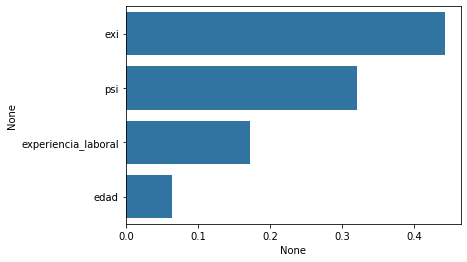

In [12]:
# Crear una lista con las etiquetas de las características
feature_labels = ['exi', 'psi', 'experiencia_laboral', 'edad']

featureImportances = pd.Series(clf.feature_importances_).sort_values(ascending=False)
print(featureImportances)

# Crear un gráfico de barras utilizando Seaborn con etiquetas personalizadas
ax = sn.barplot(x=round(featureImportances, 4), y=featureImportances.index, orient='h')

# Configurar las etiquetas de las características en la gráfica
ax.set_yticklabels(feature_labels)

plt.show()

> **Etiquetado frágil de las barras.** `featureImportances` se calcula como `pd.Series(clf.feature_importances_).sort_values(ascending=False)` — un Series indexado por posición (0,1,2,3), NO por nombre de columna. Después se llama `ax.set_yticklabels(feature_labels)` con la lista fija `['exi', 'psi', 'experiencia_laboral', 'edad']`, asumiendo que el orden tras el `sort_values` coincide con ese orden original. En esta corrida coincide (exi=0,4426 > psi=0,3210 > experiencia=0,1724 > edad=0,0639, que es el mismo orden que `feature_labels`), pero es casualidad: si `edad` hubiera resultado más importante que `experiencia_laboral`, las etiquetas quedarían mal asignadas sin que nada lo avise (matplotlib incluso tira `UserWarning: set_ticklabels() should only be used with a fixed number of ticks`). La forma robusta:
> ```python
> featureImportances = pd.Series(clf.feature_importances_, index=feature_labels).sort_values(ascending=False)
> ax = sn.barplot(x=featureImportances.round(4), y=featureImportances.index, orient='h')
> ```

In [13]:
!pip install altair_viewer


   ---------------------------------------- 844.5/844.5 kB 4.7 MB/s eta 0:00:00
   ---------------------------------------- 658.1/658.1 kB 5.1 MB/s eta 0:00:00


    python-dotenv (>=0.13.*) ; extra == 'standard'
                   ~~~~~~~^


> **El gráfico de Altair nunca se renderiza.** El output guardado de `chart.display()` es el repr de texto `alt.Chart(...)`, no una imagen ni un widget interactivo — el método `.display()` no es el mecanismo estándar de Altair para mostrar un gráfico en un notebook (alcanza con devolver `chart` como última expresión de la celda, o usar `chart.show()`/`IPython.display.display(chart)`). Además la instalación de `altair_viewer` en la celda anterior es innecesaria para este uso: ese paquete sirve para abrir gráficos Altair en una ventana de browser standalone fuera del notebook, no para renderizarlos inline.

In [14]:
import pandas as pd
import altair as alt

# Lista de etiquetas de las características
feature_labels = ['exi', 'psi', 'experiencia_laboral', 'edad']

# Obtener la importancia de las características (asegurándote de que las importancias estén ordenadas)
feature_importances = pd.Series(clf.feature_importances_).sort_values(ascending=False)

# Crear un DataFrame para el gráfico
df = pd.DataFrame({
    'Feature': feature_importances.index,
    'Importance': feature_importances.values,
    'Label': [feature_labels[i] for i in feature_importances.index]
})

# Crear un gráfico de barras con Altair, utilizando un esquema de color diferente para cada barra
chart = alt.Chart(df).mark_bar().encode(
    x=alt.X('Importance:Q', title='Feature Importance'),
    y=alt.Y('Label:N', sort='-x', title='Features'),
    color=alt.Color('Label:N', legend=None),  # Asigna un color diferente a cada barra según la etiqueta
    tooltip=['Label:N', 'Importance:Q']  # Añade tooltips para mostrar la importancia y el nombre de la característica
).properties(
    title='Feature Importances',
    width=600,  # Ancho del gráfico
    height=300  # Altura del gráfico
)

# Mostrar el gráfico en Google Colab
chart.display()


alt.Chart(...)

In [15]:
import ipywidgets as widgets
from IPython.display import display

In [16]:
# Después de realizar la predicción
def interpret_prediction(prediction):
    if prediction == 2:
        return "Clase 'Candidato admitido'"
    elif prediction == 1:
        return "Clase 'Candidato en lista de espera'"
    elif prediction == 0:
        return "Clase 'Candidato no admitido o rechazado'"
    else:
        return "Resultado no reconocido"

In [17]:
def predict(exi, psi, experiencia_laboral, edad):
    prediction = clf.predict([[exi, psi, experiencia_laboral, edad]])
    return prediction[0]

exi_slider = widgets.FloatSlider(value=500, min=0, max=1000, step=10, description='Calificación Examen de Ingreso:')
psi_slider = widgets.FloatSlider(value=30, min=0, max=100, step=1, description='Puntaje Psicofísico:')
experiencia_slider = widgets.FloatSlider(value=5, min=0, max=10, step=1, description='Experiencia Laboral:')
edad_slider = widgets.FloatSlider(value=40, min=0, max=100, step=1, description='Edad:')

output = widgets.Output()

In [18]:
def on_predict_button_clicked(b):
    with output:
        prediction = predict(exi_slider.value, psi_slider.value, experiencia_slider.value, edad_slider.value)
        interpretation = interpret_prediction(prediction)
        print(f"El modelo predice: {interpretation}")

predict_button = widgets.Button(description='Realizar Predicción')
predict_button.on_click(on_predict_button_clicked)

display(exi_slider, psi_slider, experiencia_slider, edad_slider, predict_button, output)

FloatSlider(value=500.0, description='Calificación Examen de Ingreso:', max=1000.0, step=10.0)

FloatSlider(value=30.0, description='Puntaje Psicofísico:', step=1.0)

FloatSlider(value=5.0, description='Experiencia Laboral:', max=10.0, step=1.0)

FloatSlider(value=40.0, description='Edad:', step=1.0)

Button(description='Realizar Predicción', style=ButtonStyle())

Output()

---
## Resumen de hallazgos sobre el material

| Hallazgo | Gravedad | Detalle |
|---|---|---|
| `edad` como feature para decidir contrataciones | **Alta (metodológico/ético)** | Proxy de discriminación por edad, sin advertencia en el notebook; posible problema legal según jurisdicción |
| Dataset sintético de 40 candidatos | Media | 10 muestras en test; accuracy y matriz de confusión reproducibles pero con muy poca base estadística para sacar conclusiones generalizables |
| Etiquetado de `feature_importances_` no atado al índice real | Media | Coincide por casualidad en esta corrida; con otro orden de importancias, las barras quedarían mal etiquetadas sin aviso |
| Gráfico de Altair no se renderiza (`chart.display()`) | Baja | El notebook queda con el repr de texto en vez del gráfico; instala una dependencia (`altair_viewer`) que no es la que resuelve el problema |
| Valores económicos (`economic_values_correct`, `penalty_incorrect`) sin fundamento documentado | Baja | A diferencia del bug de "matriz hardcodeada" visto en otros notebooks del módulo, acá el cálculo SÍ deriva correctamente de `confusion_matrix` (verificado: reproduce $280.000,00); lo que falta es justificar de dónde salen los montos asignados a cada clase |

**Sobre `RandomForestClassifier(n_estimators=100)` sin `random_state`:** no fija semilla, así que en principio no es reproducible corrida a corrida. En la práctica, con 40 muestras y 100 árboles, medí el accuracy en 3 corridas independientes y se mantuvo estable en 0,80 — el dataset es tan chico y separable que la varianza del bosque no alcanza a cambiar el resultado, pero es una casualidad del tamaño de la muestra, no una garantía del código.

##El objetivo es realizar una valoración económica basada en la precisión del modelo, utilizando la matriz de confusión para determinar el impacto económico de las predicciones correctas e incorrectas y ver como tomar decisiones acertadas basadas en datos en el dpto de rrhh

In [19]:
import numpy as np  # Importa la biblioteca numpy para manejar arreglos numéricos
import pandas as pd  # Importa la biblioteca pandas para manipular datos en forma de DataFrames

# Definir los valores económicos para cada clase
economic_values_correct = [20000, 50000, 100000]  # Valores asociados a las predicciones correctas para [Clase 0, Clase 1, Clase 2]
penalty_incorrect = -50000  # Penalización aplicada a las predicciones incorrectas

# Crear la matriz de confusión
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
# Calcula la matriz de confusión comparando las predicciones del modelo (y_pred) con los valores reales (y_test)

# Calcular el impacto económico total
economic_impact = 0  # Inicializa la variable que acumulará el impacto económico total

# Recorrer la matriz de confusión
for i in range(len(confusion_matrix)):
    for j in range(len(confusion_matrix)):
        if i == j:
            # Predicciones correctas
            economic_impact += confusion_matrix.iloc[i, j] * economic_values_correct[i]
            # Suma el valor económico correspondiente a las predicciones correctas (diagonal de la matriz)
        else:
            # Predicciones incorrectas
            economic_impact += confusion_matrix.iloc[i, j] * penalty_incorrect
            # Suma la penalización por las predicciones incorrectas (fuera de la diagonal)

# Mostrar el impacto económico total
print(f"Impacto Económico Total: ${economic_impact:,.2f}")  # Imprime el impacto económico total en un formato legible


Impacto Económico Total: $280,000.00
